In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVR
from sklearn.metrics import mean_squared_error, r2_score

In [16]:
diabetes = load_diabetes()
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df['target'] = diabetes.target

In [17]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.268604e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


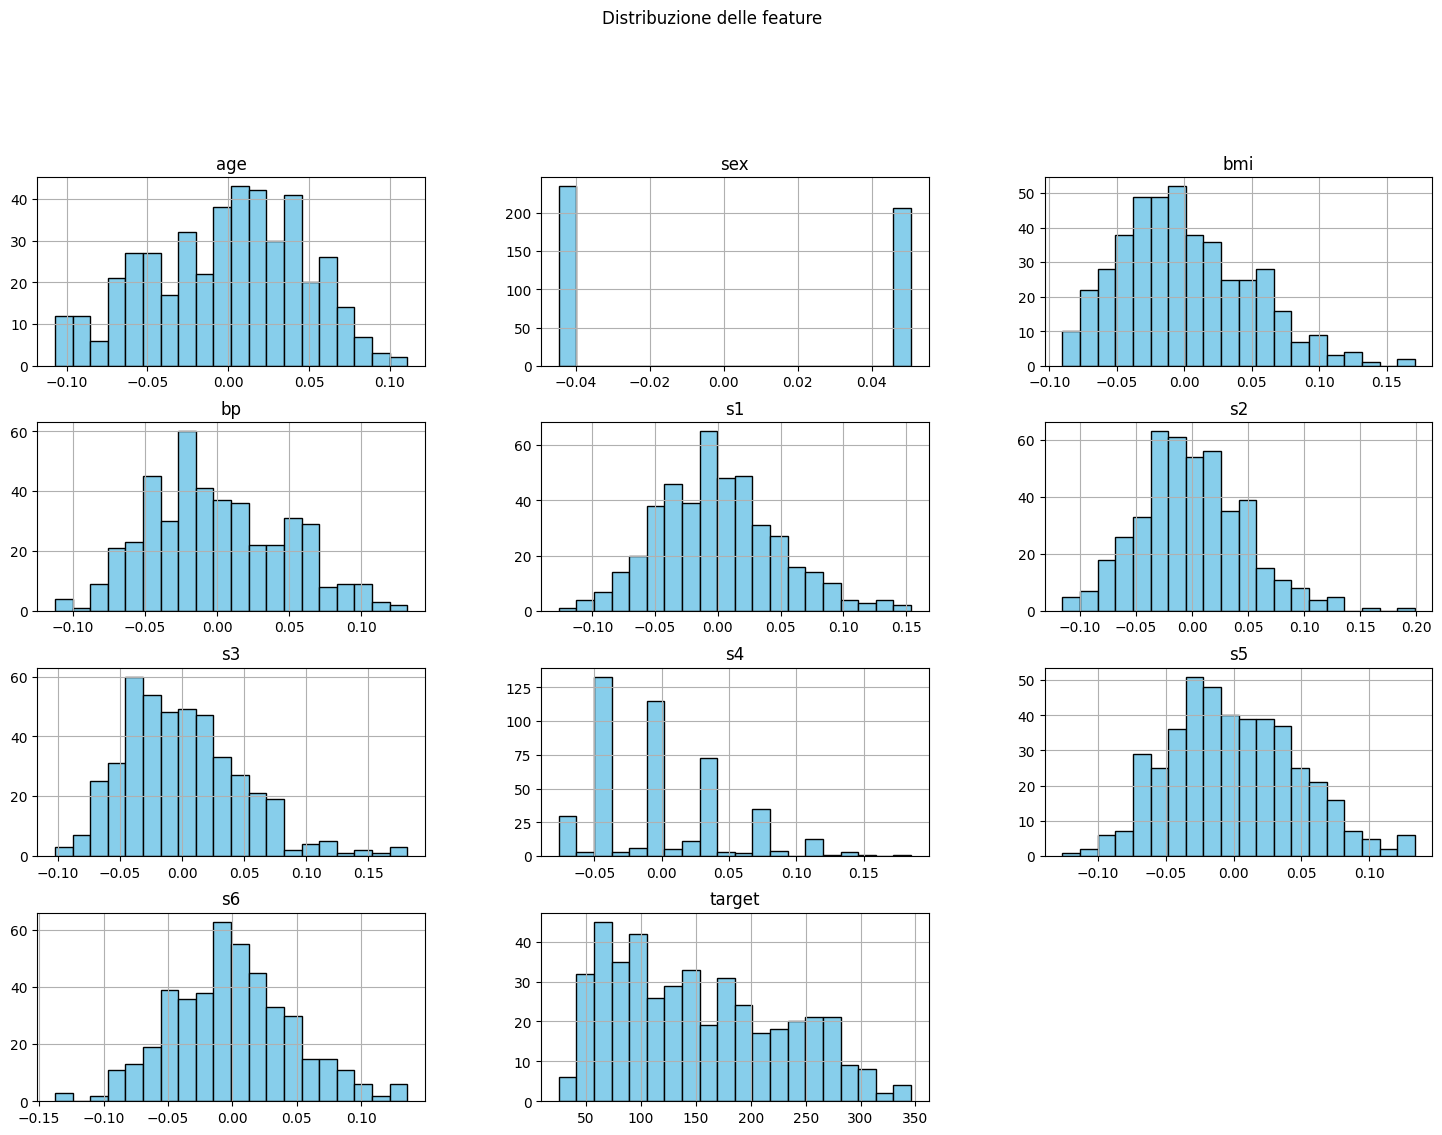

In [18]:
df.hist(bins=20, figsize=(18,12), color='skyblue', edgecolor='black')
plt.suptitle("Distribuzione delle feature", y=1.02)
plt.show()

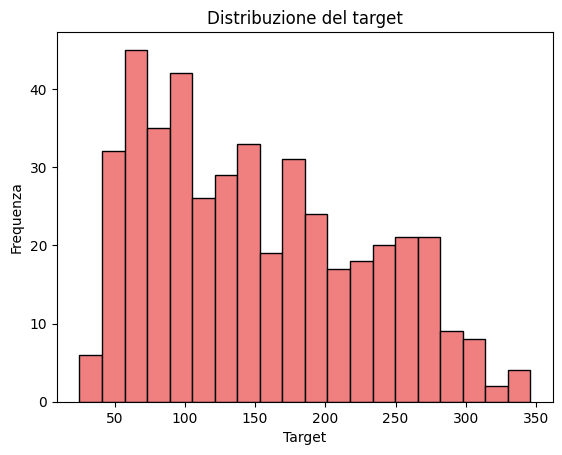

In [19]:
plt.hist(df['target'], bins=20, color='lightcoral', edgecolor='black')
plt.title("Distribuzione del target")
plt.xlabel("Target")
plt.ylabel("Frequenza")
plt.show()

In [20]:
features = ['bmi', 'bp']
X = df[features].values
y = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [22]:
model = LinearSVR(C=1.0, epsilon=0.1, max_iter=10000, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [23]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.2f}")
print(f"R²: {r2:.2f}")

MSE: 4802.48
R²: 0.09


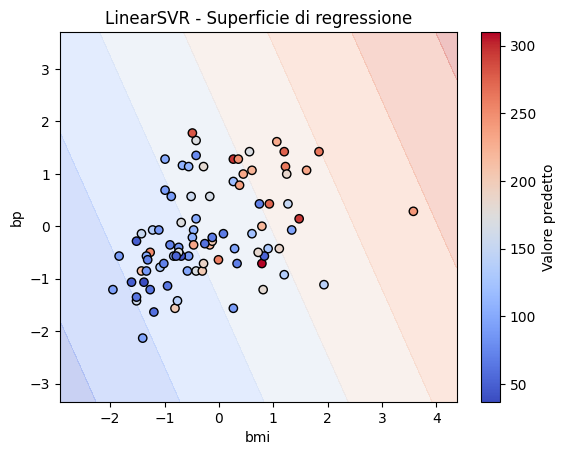

In [24]:
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 100),
    np.linspace(y_min, y_max, 100)
)

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X_test[:,0], X_test[:,1], c=y_test,
            cmap=plt.cm.coolwarm, edgecolors='k')

plt.xlabel(features[0])
plt.ylabel(features[1])
plt.title("LinearSVR - Superficie di regressione")
plt.colorbar(label="Valore predetto")
plt.show()

In [25]:
features_all = diabetes.feature_names
X_all = df[features_all].values

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_all, y, test_size=0.2, random_state=42)

In [26]:
scaler_all = StandardScaler()
X_train_b = scaler_all.fit_transform(X_train_b)
X_test_b = scaler_all.transform(X_test_b)

In [27]:
model_all = LinearSVR(C=1.0, epsilon=0.1, max_iter=10000, random_state=42)
model_all.fit(X_train_b, y_train_b)
y_pred_all = model_all.predict(X_test_b)

In [28]:
mse_all = mean_squared_error(y_test_b, y_pred_all)
r2_all = r2_score(y_test_b, y_pred_all)

print(f"MSE (tutte le feature): {mse_all:.2f}")
print(f"R² (tutte le feature): {r2_all:.2f}")

MSE (tutte le feature): 3839.82
R² (tutte le feature): 0.28
